# Aaliyah John-Harry
# DATA 612 Project 2: Content-Based and Collaborative Filtering Recommenders
## 06/12/2026

### Objective

The goal of this project is to compare multiple recommendation approaches. I should implement at least two of these algorithms:

1. Content-Based Filtering
2. User-User Collaborative Filtering
3. Item-Item Collaborative Filtering

#### Content-Based Filtering

Content-based recommenders recommend items that are similar to items a user has previously liked.

For movies, similarity can be computed using metadata like:
- Genres
- Keywords
- Descriptions
- Reviews

#### User-user collaborative filtering 

This identifies users with similar rating behavior and recommends items liked by similar users.

#### Item-item collaborative filtering 

## Dataset 

I used a MovieLens dataset that represents users, movies, and ratings as a sparse user-item matrix. It contains ~100,000 ratings.

Most users only rate a small portion of all movies, which is common in recommender systems. 

In [2]:
import os
import zipfile
import urllib.request
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import mean_squared_error

pd.set_option('display.max_columns', 50)
RANDOM_STATE = 2705
np.random.seed(RANDOM_STATE)

In [3]:
DATA_DIR = Path('data')
DATA_DIR.mkdir(exist_ok=True)

url = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
zip_path = DATA_DIR / 'ml-latest-small.zip'
extract_dir = DATA_DIR / 'ml-latest-small'

if not extract_dir.exists():
    print('Downloading MovieLens latest-small dataset...')
    urllib.request.urlretrieve(url, zip_path)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA_DIR)
else:
    print('Dataset already downloaded.')

ratings = pd.read_csv(extract_dir / 'ratings.csv')
movies = pd.read_csv(extract_dir / 'movies.csv')

print(ratings.shape)
print(movies.shape)
ratings.head(10)

Dataset already downloaded.
(100836, 4)
(9742, 3)


,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931
5,1,70,3.0,964982400
6,1,101,5.0,964980868
7,1,110,4.0,964982176
8,1,151,5.0,964984041
9,1,157,5.0,964984100


In [4]:
movies.head(10)

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy
5,6,Heat (1995),Action|Crime|Thriller
6,7,Sabrina (1995),Comedy|Romance
7,8,Tom and Huck (1995),Adventure|Children
8,9,Sudden Death (1995),Action
9,10,GoldenEye (1995),Action|Adventure|Thriller


## Data Exploration

Before modeling, I inspected the number of users, movies, ratings, and sparsity(how many user-movie combinations are missing ratings).

In [5]:
n_users = ratings['userId'].nunique()
n_movies = ratings['movieId'].nunique()
n_ratings = len(ratings)
sparsity = 1 - (n_ratings / (n_users * n_movies))

summary = pd.DataFrame({
    'Metric': ['Users', 'Movies with ratings', 'Ratings', 'Sparsity'],
    'Value': [n_users, n_movies, n_ratings, f'{sparsity:.2%}']
})
summary

,Metric,Value
0,Users,610
1,Movies with ratings,9724
2,Ratings,100836
3,Sparsity,98.30%


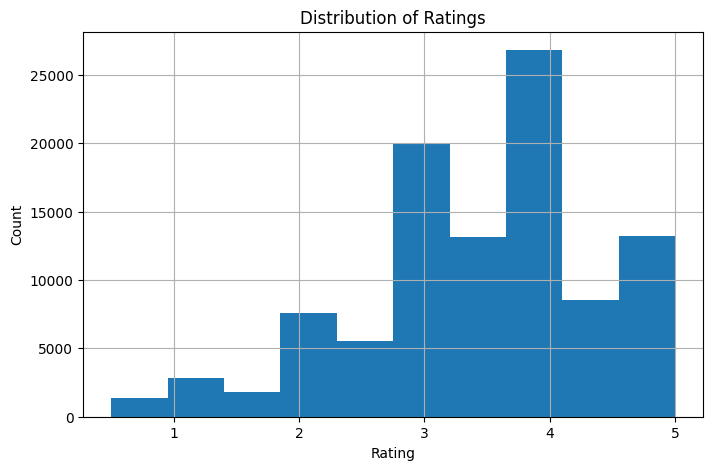

In [6]:
plt.figure(figsize=(8, 5))
ratings['rating'].hist(bins=10)
plt.title('Distribution of Ratings')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.show()

## Training and Test Data

- I split the dataset into training and test sets, with 80% of the ratings assigned to the training set and 20% to the test set.
- The training data will be used to build the recommenders, while the test set will be used for evaluation
- Most users haven't rated every movie, so the dataset contains many missing values.
    - I replaced these missing ratings with zeros to create a complete matrix that the collaborative filtering algorithms can use.

In [7]:
train_df, test_df = train_test_split(
    ratings,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=ratings['userId']
)

print('Train:', train_df.shape)
print('Test:', test_df.shape)

Train: (80668, 4)
Test: (20168, 4)


In [8]:
train_matrix = train_df.pivot_table(
    index='userId',
    columns='movieId',
    values='rating'
)

train_matrix_filled = train_matrix.fillna(0)

train_matrix.shape

(610, 9028)

## Baseline Model

- I created a simple baseline model by calculating the global average rating from the training data and using that value as the prediction for every movie in the test set.
- This is a benchmark for comparison and represents the simplest possible recommender, since it does not account for differences between users or movies.
- The RMSE (1.0521) gives me a reference point for evaluating whether the more advanced recommendation methods that I will use in this project would improve prediction accuracy.

In [9]:
global_mean = train_df['rating'].mean()

def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))

baseline_preds = np.full(len(test_df), global_mean)
baseline_rmse = rmse(test_df['rating'], baseline_preds)

print(f'Global mean rating: {global_mean:.3f}')
print(f'Baseline RMSE: {baseline_rmse:.4f}')

Global mean rating: 3.502
Baseline RMSE: 1.0521


## Content-Based Filtering Using Genres

- To build the content-based recommender, I converted movie genres into a binary feature matrix using MultiLabelBinarizer.
- Each genre became its own column, where 1 indicates that the movie belongs to that genre and 0 indicates that it does not.
    - This is so that the movie genres can be treated as numerical features and similarity calculations can be performed between the movies.
 
## Building User Profiles

- I  built a profile for each user based on the genres of movies they rated in the training data.
- I centered the ratings around each user's average rating so that movies rated above their typical rating contributed positively to the profile, while movies rated below their average contributed negatively.
    - This gave me a weighted genre preference vector for each user's interests.

## Generating Content-Based Predictions

- Using the user profiles, I generated predictions by comparing each user's genre preference vector with the genre vector of a movie using cosine similarity.
- I added the similarity score to the user's average rating to estimate how much they would like the movie.
- The predicted ratings were clipped to the valid MovieLens rating range (0.5–5.0) and evaluated using RMSE.

## Results

- The content-based filtering model achieved an RMSE of 0.9344, which was an improvement over the baseline model.
- This means that incorporating movie genre information and user genre preferences produced more accurate rating predictions than simply using the global average rating for all users and movies.

In [10]:
movies_cb = movies.copy()
movies_cb['genre_list'] = movies_cb['genres'].replace('(no genres listed)', '').str.split('|')
movies_cb['genre_list'] = movies_cb['genre_list'].apply(lambda x: [] if x == [''] else x)

mlb = MultiLabelBinarizer()
genre_features = pd.DataFrame(
    mlb.fit_transform(movies_cb['genre_list']),
    index=movies_cb['movieId'],
    columns=mlb.classes_
)

genre_features.head(10)

,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
movieId,,,,,,,,,,,,,,,,,,,
1,0,1,1,1,1,0,0,0,1,0,0,0,0,0,0,0,0,0,0
2,0,1,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0
5,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0
7,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0
8,0,1,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
9,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [11]:
def build_user_profiles(train_df, genre_features):
    profiles = {}
    user_means = train_df.groupby('userId')['rating'].mean().to_dict()

    for user_id, group in train_df.groupby('userId'):
        movie_ids = group['movieId'].values
        valid_movie_ids = [m for m in movie_ids if m in genre_features.index]
        if not valid_movie_ids:
            continue

        user_ratings = group.set_index('movieId').loc[valid_movie_ids, 'rating']
        centered_ratings = user_ratings - user_means[user_id]
        item_vectors = genre_features.loc[valid_movie_ids]

        if np.isclose(np.abs(centered_ratings).sum(), 0):
            profile = item_vectors.mean(axis=0)
        else:
            profile = item_vectors.mul(centered_ratings, axis=0).sum(axis=0) / np.abs(centered_ratings).sum()
        profiles[user_id] = profile

    return pd.DataFrame(profiles).T.fillna(0), user_means

user_profiles, user_means = build_user_profiles(train_df, genre_features)
user_profiles.head()

,Action,Adventure,Animation,Children,Comedy,Crime,Documentary,Drama,Fantasy,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
1,-0.055087,-0.032000,0.052217,0.037522,-0.027000,0.014435,0.000000,0.103261,-0.041435,0.000000,-0.091739,0.000000,0.054565,-0.013957,-0.017478,-0.037174,-0.078043,0.004130,-0.010435
2,0.039634,-0.024390,0.000000,0.000000,0.134146,-0.044207,0.021341,-0.060976,0.000000,0.000000,0.000000,-0.038110,0.000000,0.010671,0.045732,-0.083841,-0.195122,0.045732,-0.024390
3,0.258264,0.055785,-0.093750,-0.125000,-0.218750,-0.062500,0.000000,-0.342200,0.018337,0.000000,0.204804,0.000000,-0.031250,0.040806,-0.125000,0.386364,0.189566,-0.093750,0.000000
4,-0.025220,0.005421,0.014647,0.011382,0.002306,0.033247,0.007548,-0.026748,-0.005961,0.009465,0.014647,-0.002816,0.021296,-0.004493,-0.043791,-0.038070,-0.004822,0.014198,0.005751
5,-0.109000,-0.039000,0.136000,0.134000,-0.078000,0.064000,0.000000,0.104000,0.136000,0.000000,0.000000,0.022000,0.125000,0.011000,-0.192000,-0.083000,0.055000,-0.037000,-0.048000


In [12]:
def predict_content_based(test_df, user_profiles, genre_features, user_means, global_mean):
    preds = []
    for row in test_df.itertuples(index=False):
        user_id = row.userId
        movie_id = row.movieId

        if user_id not in user_profiles.index or movie_id not in genre_features.index:
            preds.append(global_mean)
            continue

        user_vec = user_profiles.loc[[user_id]]
        movie_vec = genre_features.loc[[movie_id]]
        sim = cosine_similarity(user_vec, movie_vec)[0, 0]

        pred = user_means.get(user_id, global_mean) + sim
        preds.append(np.clip(pred, 0.5, 5.0))
    return np.array(preds)

cb_preds = predict_content_based(test_df, user_profiles, genre_features, user_means, global_mean)
cb_rmse = rmse(test_df['rating'], cb_preds)
print(f'Content-Based RMSE: {cb_rmse:.4f}')

Content-Based RMSE: 0.9344


## User-User Collaborative Filtering

User-user collaborative filtering finds users with similar rating patterns.

## Calculating User Similarity
- For the user-user recommender, I represented each user by their movie ratings and centered those ratings around the user's average rating.
    - This helps remove differences in rating behavior, like users who consistently rate movies higher or lower than others.
- I calculated cosine similarity between users to identify users with similar rating patterns.
- The resulting matrix measured how closely each user's preferences aligned with every other user in the dataset.

## Generating User-User Predictions
- To predict a rating, I identified the most similar users who had already rated the target movie.
- I experimented with a couple of neighborhood sizes (k = 10, 20, and 40) to evaluate the impact of using more/less neighbors.
- I calculated the predicted ratings using a weighted average of neighbor ratings, where more similar users contributed more heavily to the final prediction.
- The predicted ratings were clipped to the valid MovieLens rating range (0.5–5.0) and evaluated using RMSE.

## Results
- The User-User Collaborative Filtering model outperformed both the baseline model and the content-based model.
- The best performance was achieved with k = 20, with RMSE=0.8872.
- These results show that users with similar rating histories can provide valuable information for predicting future preferences.

In [13]:
user_means_series = train_matrix.mean(axis=1)
train_user_centered = train_matrix.sub(user_means_series, axis=0).fillna(0)
user_similarity = pd.DataFrame(
    cosine_similarity(train_user_centered),
    index=train_matrix.index,
    columns=train_matrix.index
)

user_similarity.iloc[:5, :5]

userId,1,2,3,4,5
userId,,,,,
1,1.000000,0.002423,-0.001080,0.023519,0.054140
2,0.002423,1.000000,0.000000,-0.026078,0.027103
3,-0.001080,0.000000,1.000000,-0.014453,-0.038668
4,0.023519,-0.026078,-0.014453,1.000000,-0.003399
5,0.054140,0.027103,-0.038668,-0.003399,1.000000


In [14]:
def predict_user_user(test_df, train_matrix, user_similarity, user_means_series, global_mean, k=20):
    preds = []
    for row in test_df.itertuples(index=False):
        user_id = row.userId
        movie_id = row.movieId

        if user_id not in train_matrix.index or movie_id not in train_matrix.columns:
            preds.append(global_mean)
            continue

        movie_ratings = train_matrix[movie_id].dropna()
        if movie_ratings.empty:
            preds.append(user_means_series.get(user_id, global_mean))
            continue

        sims = user_similarity.loc[user_id, movie_ratings.index].drop(index=user_id, errors='ignore')
        movie_ratings = movie_ratings.loc[sims.index]

        top_sims = sims.abs().sort_values(ascending=False).head(k).index
        sims_k = sims.loc[top_sims]
        ratings_k = movie_ratings.loc[top_sims]
        neighbor_means = user_means_series.loc[top_sims]

        denom = np.abs(sims_k).sum()
        if denom == 0:
            pred = user_means_series.get(user_id, global_mean)
        else:
            pred = user_means_series.get(user_id, global_mean) + np.dot(sims_k, ratings_k - neighbor_means) / denom
        preds.append(np.clip(pred, 0.5, 5.0))
    return np.array(preds)

user_k_values = [10, 20, 40]
user_user_results = []

for k in user_k_values:
    preds = predict_user_user(test_df, train_matrix, user_similarity, user_means_series, global_mean, k=k)
    user_user_results.append({'model': f'User-User CF (k={k})', 'rmse': rmse(test_df['rating'], preds)})

pd.DataFrame(user_user_results)

,model,rmse
0,User-User CF (k=10),0.893382
1,User-User CF (k=20),0.887169
2,User-User CF (k=40),0.887340


## Item-Item Collaborative Filtering

Item-item collaborative filtering compares movies based on how users rated them. For a target movie, the prediction is based on the user's ratings for similar movies.

## Calculating Item Similarity
- For the item-item recommender, I represented each movie by the ratings it received from users in the training data.
- I centered the ratings around each movie's average rating to account for movies that are generally rated higher or lower overall.
- I calculated cosine similarity between movies to identify items with similar rating patterns.
- This means movies were considered similar if users tended to rate them in similar ways.

## Generating Item-Item Predictions
- To predict a user's rating for a movie, I looked at other movies that the same user had already rated.
- I selected the most similar movies using different neighborhood sizes (k = 10, 20, and 40).
- I calculated the prediction as a weighted average of the user's ratings for similar movies, adjusted around each movie's average rating.
- The predicted ratings were clipped to the valid MovieLens rating range (0.5–5.0) and evaluated using RMSE.

## Results
- The item-item collaborative filtering model improved as the neighborhood size increased.
- The best item-item result was with k = 40, with an RMSE of 0.9172.
- This performed better than the baseline and content-based models, but not as well as the user-user collaborative filtering model.
- This shows that item rating patterns were useful for prediction, but in this dataset, similar users provided slightly stronger signals than similar movies.

In [15]:
item_means_series = train_matrix.mean(axis=0)
train_item_centered = train_matrix.sub(item_means_series, axis=1).fillna(0)
item_similarity = pd.DataFrame(
    cosine_similarity(train_item_centered.T),
    index=train_matrix.columns,
    columns=train_matrix.columns
)

item_similarity.iloc[:5, :5]

movieId,1,2,3,4,5
movieId,,,,,
1,1.000000,0.052519,0.110582,0.000000,0.078836
2,0.052519,1.000000,0.107633,0.023651,0.162357
3,0.110582,0.107633,1.000000,0.081829,0.207465
4,0.000000,0.023651,0.081829,1.000000,0.000000
5,0.078836,0.162357,0.207465,0.000000,1.000000


In [16]:
def predict_item_item(test_df, train_matrix, item_similarity, item_means_series, user_means_series, global_mean, k=20):
    preds = []
    for row in test_df.itertuples(index=False):
        user_id = row.userId
        movie_id = row.movieId

        if user_id not in train_matrix.index or movie_id not in train_matrix.columns:
            preds.append(global_mean)
            continue

        user_ratings = train_matrix.loc[user_id].dropna()
        if user_ratings.empty:
            preds.append(user_means_series.get(user_id, global_mean))
            continue

        candidate_items = user_ratings.index.intersection(item_similarity.columns)
        sims = item_similarity.loc[movie_id, candidate_items].drop(index=movie_id, errors='ignore')
        user_ratings = user_ratings.loc[sims.index]

        top_items = sims.abs().sort_values(ascending=False).head(k).index
        sims_k = sims.loc[top_items]
        ratings_k = user_ratings.loc[top_items]
        item_means_k = item_means_series.loc[top_items]

        denom = np.abs(sims_k).sum()
        if denom == 0:
            pred = item_means_series.get(movie_id, global_mean)
        else:
            pred = item_means_series.get(movie_id, global_mean) + np.dot(sims_k, ratings_k - item_means_k) / denom
        preds.append(np.clip(pred, 0.5, 5.0))
    return np.array(preds)

item_k_values = [10, 20, 40]
item_item_results = []

for k in item_k_values:
    preds = predict_item_item(test_df, train_matrix, item_similarity, item_means_series, user_means_series, global_mean, k=k)
    item_item_results.append({'model': f'Item-Item CF (k={k})', 'rmse': rmse(test_df['rating'], preds)})

pd.DataFrame(item_item_results)

,model,rmse
0,Item-Item CF (k=10),0.927617
1,Item-Item CF (k=20),0.918988
2,Item-Item CF (k=40),0.917238


## RMSE Results Comparison

All recommendation methods outperformed the baseline, so incorporating user behavior or movie characteristics clearly improved the prediction accuracy.

- User-User Collaborative Filtering had the lowest RMSE values overall, with the best result of 0.8872 at k = 20 - the strongest-performing model.
- Item-Item Collaborative Filtering also performed well, while the Content-Based model improved on the baseline but was less accurate than both collaborative filtering approaches.

### Limitations and Considerations
- Although User-User Collaborative Filtering achieved the best RMSE, it may struggle with new users who have little or no rating history.
- Content-Based Filtering can recommend movies even when limited rating data exists, but it tends to recommend movies that are very similar to those a user has already seen.
- RMSE only measures prediction accuracy and does not capture other important aspects of recommendation quality like diversity and novelty.
- In a real-world scenario, additional evaluation metrics and user engagement measures would be needed to determine which recommender provides the best overall user experience.

In [17]:
results = pd.DataFrame([
    {'model': 'Global Mean Baseline', 'rmse': baseline_rmse},
    {'model': 'Content-Based Genres', 'rmse': cb_rmse},
] + user_user_results + item_item_results)

results = results.sort_values('rmse').reset_index(drop=True)
results

,model,rmse
0,User-User CF (k=20),0.887169
1,User-User CF (k=40),0.887340
2,User-User CF (k=10),0.893382
3,Item-Item CF (k=40),0.917238
4,Item-Item CF (k=20),0.918988
5,Item-Item CF (k=10),0.927617
6,Content-Based Genres,0.934393
7,Global Mean Baseline,1.052141


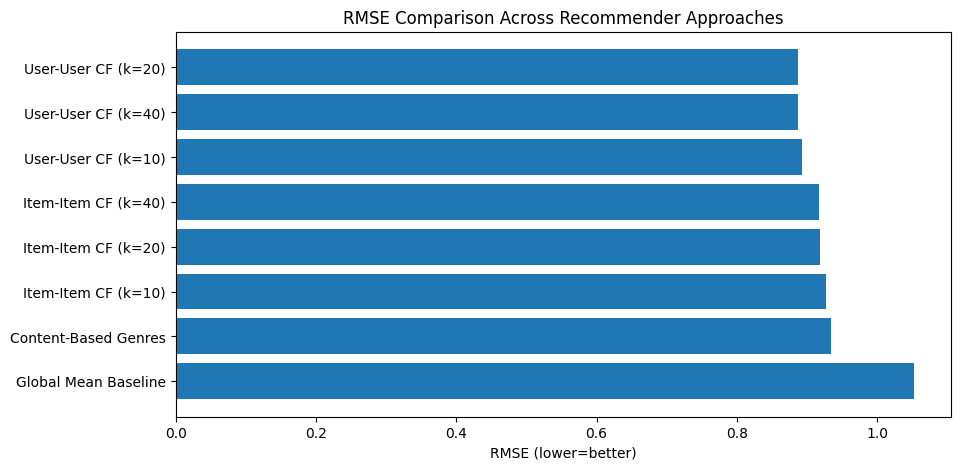

In [18]:
plt.figure(figsize=(10, 5))
plt.barh(results['model'], results['rmse'])
plt.xlabel('RMSE (lower=better)')
plt.title('RMSE Comparison Across Recommender Approaches')
plt.gca().invert_yaxis()
plt.show()

## Revised Precision@10 Evaluation

In the original evaluation, candidate movies were restricted to the 500 most popular unseen items, which introduced popularity bias into the ranking process. To provide a fairer evaluation of the collaborative filtering models, I revised the candidate-generation strategy so that each user's candidate set consists of their relevant test-set movies together with a random sample of unseen non-relevant movies. This allows the collaborative filtering models to rank items based primarily on their predicted relevance rather than popularity.


In [19]:
def get_seen_items(train_df):
    return train_df.groupby('userId')['movieId'].apply(set).to_dict()

seen_items = get_seen_items(train_df)
all_movie_ids = set(movies['movieId'])

test_relevant = (
    test_df[test_df['rating'] >= 4.0]
    .groupby('userId')['movieId']
    .apply(set)
    .to_dict()
)

eval_users = [u for u in test_relevant if u in train_matrix.index]
len(eval_users)

604

In [26]:
def precision_at_k(recommendations, relevant_items, k=10):
    if not relevant_items:
        return np.nan
    recs_k = recommendations[:k]
    hits = len(set(recs_k).intersection(relevant_items))
    return hits / k


popular_movies = train_df.groupby('movieId')['rating'].count().sort_values(ascending=False).index.tolist()


def get_eval_candidates(user_id, n_negatives=500, random_state=42):
    rng = np.random.default_rng(random_state + int(user_id))

    seen = seen_items.get(user_id, set())
    relevant = test_relevant.get(user_id, set())

    unseen = list(all_movie_ids - seen)
    non_relevant = list(set(unseen) - relevant)

    sampled_negatives = rng.choice(
        non_relevant,
        size=min(n_negatives, len(non_relevant)),
        replace=False
    ).tolist()

    candidates = list(relevant) + sampled_negatives
    return candidates


def recommend_content_based(user_id, n=10):
    candidates = list(set(genre_features.index) - seen_items.get(user_id, set()))

    if user_id not in user_profiles.index:
        return [m for m in popular_movies if m in candidates][:n]

    user_vec = user_profiles.loc[[user_id]]
    movie_vecs = genre_features.loc[candidates]
    sims = cosine_similarity(user_vec, movie_vecs)[0]

    ranked = pd.Series(sims, index=candidates).sort_values(ascending=False)
    return ranked.head(n).index.tolist()


def recommend_user_user(user_id, n=10, k_neighbors=20, n_negatives=500):
    if user_id not in train_matrix.index:
        return popular_movies[:n]

    candidates = get_eval_candidates(user_id, n_negatives=n_negatives)
    candidates = [m for m in candidates if m in train_matrix.columns]

    if not candidates:
        return []

    # Select the most similar users
    sims = user_similarity.loc[user_id].drop(index=user_id, errors='ignore')
    top_users = sims.abs().sort_values(ascending=False).head(k_neighbors).index
    sims_k = sims.loc[top_users]

    # Center neighbor ratings around each neighbor's mean
    neighbor_ratings = train_matrix.loc[top_users, candidates]
    neighbor_deviations = neighbor_ratings.sub(user_means_series.loc[top_users], axis=0)

    # Only count neighbors who actually rated each candidate movie
    rated_mask = neighbor_ratings.notna()
    weighted_sum = neighbor_deviations.mul(sims_k, axis=0).sum(axis=0, skipna=True)
    denom = rated_mask.mul(np.abs(sims_k), axis=0).sum(axis=0)

    # Add the active user's mean back to get predictions on the original rating scale.
    preds = user_means_series.loc[user_id] + (weighted_sum / denom.replace(0, np.nan))
    preds = preds.fillna(user_means_series.loc[user_id]).clip(0.5, 5.0)

    return preds.sort_values(ascending=False).head(n).index.tolist()


def recommend_item_item(user_id, n=10, k_neighbors=20, n_negatives=500):
    if user_id not in train_matrix.index:
        return popular_movies[:n]

    user_ratings = train_matrix.loc[user_id].dropna()
    if user_ratings.empty:
        return [m for m in popular_movies if m in train_matrix.columns][:n]

    candidates = get_eval_candidates(user_id, n_negatives=n_negatives)
    candidates = [m for m in candidates if m in train_matrix.columns and m not in user_ratings.index]

    if not candidates:
        return []

    preds = {}

    for movie_id in candidates:
        if movie_id not in item_similarity.index:
            preds[movie_id] = user_means_series.get(user_id, global_mean)
            continue

        sims = item_similarity.loc[movie_id, user_ratings.index].drop(index=movie_id, errors='ignore')
        if sims.empty:
            preds[movie_id] = user_means_series.get(user_id, global_mean)
            continue

        top_items = sims.abs().sort_values(ascending=False).head(k_neighbors).index
        sims_k = sims.loc[top_items]
        ratings_k = user_ratings.loc[top_items]
        item_means_k = item_means_series.loc[top_items]

        denom = np.abs(sims_k).sum()
        if denom == 0:
            pred = user_means_series.get(user_id, global_mean)
        else:
            pred = item_means_series.get(movie_id, global_mean) + np.sum(sims_k * (ratings_k - item_means_k)) / denom

        preds[movie_id] = np.clip(pred, 0.5, 5.0)

    ranked = pd.Series(preds).sort_values(ascending=False)
    return ranked.head(n).index.tolist()


In [27]:
best_user_k = int(
    results[results['model'].str.contains('User-User', regex=False)]
    .iloc[0]['model']
    .split('=')[1]
    .replace(')', '')
)

best_item_k = int(
    results[results['model'].str.contains('Item-Item', regex=False)]
    .iloc[0]['model']
    .split('=')[1]
    .replace(')', '')
)

precision_rows = []

for name, recommender_func in [
    ('Content-Based Genres',
     lambda u: recommend_content_based(u, n=10)),

    (f'User-User CF (k={best_user_k})',
     lambda u: recommend_user_user(
         u,
         n=10,
         k_neighbors=best_user_k,
         n_negatives=500
     )),

    (f'Item-Item CF (k={best_item_k})',
     lambda u: recommend_item_item(
         u,
         n=10,
         k_neighbors=best_item_k,
         n_negatives=500
     )),
]:
    scores = []

    for user_id in eval_users:
        recs = recommender_func(user_id)
        scores.append(
            precision_at_k(
                recs,
                test_relevant[user_id],
                k=10
            )
        )

    precision_rows.append({
        'model': name,
        'precision_at_10': np.nanmean(scores)
    })

precision_results = (
    pd.DataFrame(precision_rows)
      .sort_values('precision_at_10', ascending=False)
)

precision_results

,model,precision_at_10
1,User-User CF (k=20),0.192881
2,Item-Item CF (k=40),0.080795
0,Content-Based Genres,0.006457


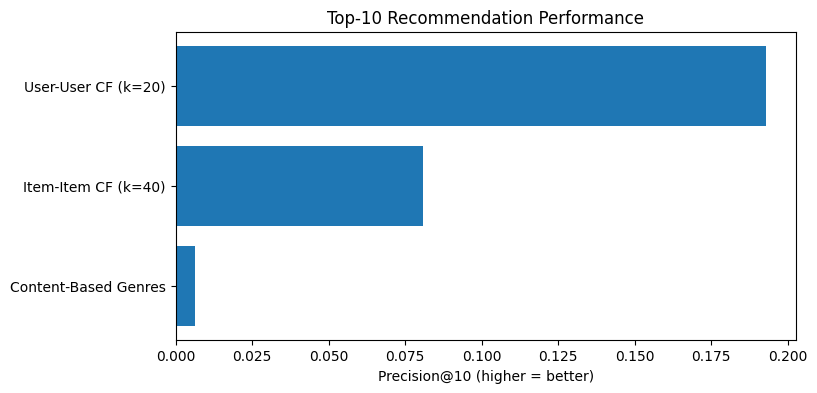

In [28]:
plt.figure(figsize=(8, 4))
plt.barh(precision_results['model'], precision_results['precision_at_10'])
plt.xlabel('Precision@10 (higher = better)')
plt.title('Top-10 Recommendation Performance')
plt.gca().invert_yaxis()
plt.show()

## Example Recommendation

The table below shows an example of the recommendations generated for a sample user. 
This is not a formal evaluation of the model, but it helps to show the kinds of movies being recommended and makes the results easier to understand beyond the performance metrics.

In [29]:
sample_user = eval_users[0]
print(f'Sample user: {sample_user}')

sample_recs = recommend_item_item(sample_user, n=10, k_neighbors=best_item_k)
movies[movies['movieId'].isin(sample_recs)][['movieId', 'title', 'genres']]

Sample user: 1


,movieId,title,genres
46,50,"Usual Suspects, The (1995)",Crime|Mystery|Thriller
911,1210,Star Wars: Episode VI - Return of the Jedi (1983),Action|Adventure|Sci-Fi
1045,1357,Shine (1996),Drama|Romance
1082,1406,La Cérémonie (1995),Crime|Drama|Mystery|Thriller
1218,1617,L.A. Confidential (1997),Crime|Film-Noir|Mystery|Thriller
1494,2019,Seven Samurai (Shichinin no samurai) (1954),Action|Adventure|Drama
1608,2150,"Gods Must Be Crazy, The (1980)",Adventure|Comedy
2020,2692,Run Lola Run (Lola rennt) (1998),Action|Crime
4694,7008,Last Tango in Paris (Ultimo tango a Parigi) (1...,Drama|Romance
5524,26547,Police Story (Ging chaat goo si) (1985),Action|Comedy|Crime|Thriller


## Conclusion and Future Improvements

In this project, I implemented and compared three recommendation approaches: Content-Based Filtering, User-User Collaborative Filtering, and Item-Item Collaborative Filtering using the MovieLens dataset. All three methods outperformed the Baseline, which highlighted that incorporating either movie characteristics or user behavior can improve rating predictions.

Based on RMSE, the User-User Collaborative Filtering model produced the strongest overall prediction performance. For ranking performance, I also evaluated Precision@10 using a revised candidate-generation process that scores all eligible unseen movies instead of pre-filtering to the most popular unseen movies. This gives a cleaner comparison because the recommendation list is driven by each model's predicted scores rather than by popularity filtering.

While the results were encouraging, each approach has limitations. Content-based filtering relies heavily on available movie metadata and may struggle to recommend items outside of a user's established interests. Collaborative filtering methods can also face challenges with new users or new movies that have limited rating history.

Several improvements could be explored in future work. Additional movie features, such as tags, plot summaries, actors, or directors, could be incorporated into the content-based model. A hybrid recommender that combines content-based and collaborative filtering techniques may also improve recommendation quality by leveraging the strengths of both approaches. Matrix factorization methods could also be explored to better capture latent patterns in user preferences and movie characteristics.
